In [1]:
import glob
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import warnings
warnings.filterwarnings('ignore')


#function to read eurostats data
def read_and_clean_eurostats(file:str, size:bool=False) -> pd.DataFrame:
    #read from file
    df = pd.read_csv(file, delimiter='\t', dtype = str)
    #expand information
    idvariables = ['datalevel', 'sectorcode', 'variable'] + (['size', 'country'] if size else ['country'])
    df[idvariables] = df.iloc[:,0].str.split(',', expand=True)
    df = df.iloc[:, 1:]

    df_long =  df.melt(
        id_vars=idvariables,
        var_name='year',
        value_name='value'
    )
    #clean strings and values
    df_long = df_long.map(lambda x: x.strip())
    df_long['value'] = pd.to_numeric(df_long['value'].str.replace(r"\D", "", regex=True), errors='coerce')
    df_long['year'] = pd.to_numeric(df_long['year'].str.replace(r"\D", "", regex=True), errors='coerce')
    #drop all that have no correct year type
    df_long = df_long.dropna(subset=['year'])

    return df_long

#function to read klems data
def read_klems_data(file: str, var: str)-> pd.DataFrame:
    df = pd.read_excel(file, sheet_name=var)
    df = df.rename(columns={'nace_r2_code': 'sectorcode', 'nace_r2_name': 'Sector', 'geo_code': 'country'})
    df = df.drop(columns=['var', 'geo_name'], axis=1)

    #make it long
    df = df.melt(['sectorcode', 'country', 'Sector'], var_name='year')
    df['year'] = pd.to_numeric(df['year'])
    df['variable'] = var

    #filter for sectors
    df = df[df['sectorcode'].isin(['C', 'F'])]

    return df


def plot_series(data: pd.DataFrame, country: str, var: str, title: str, category: str = None, ax: Axes = None) -> Axes:
    df = data[(data['country'] == country)]
    
    # Create Axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plot
    sns.lineplot(data=df, x='year', y=var, hue=category, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Value")
    
    return ax


In [2]:
#read assets from all klems files
file_list = glob.glob(os.path.join('klems data', "*.xlsx"))
klems = pd.concat([read_klems_data(file, var='I_GFCF') for file in file_list])
assets = klems.rename(columns={'value': 'assets'})
assets


,sectorcode,country,Sector,year,assets,variable
2,C,DE,Manufacturing,1995,71773.000,I_GFCF
21,F,DE,Construction,1995,8114.000,I_GFCF
60,C,DE,Manufacturing,1996,73012.002,I_GFCF
79,F,DE,Construction,1996,6983.000,I_GFCF
118,C,DE,Manufacturing,1997,74272.002,I_GFCF
...,...,...,...,...,...,...
1413,F,EL,Construction,2019,172.000,I_GFCF
1452,C,EL,Manufacturing,2020,2459.400,I_GFCF
1471,F,EL,Construction,2020,180.200,I_GFCF
1510,C,EL,Manufacturing,2021,2460.300,I_GFCF


In [3]:
#read revenue from eurostat data
eurostat = pd.concat([read_and_clean_eurostats('eurostat data/1995-2008 manufacturing 1.tsv'),
                     read_and_clean_eurostats("eurostat data/1995-2008 construction.tsv"),
                     read_and_clean_eurostats("eurostat data/1995-2008 Manufacturing 2.tsv")])
#chagne sector code to code of newere dataset
eurostat['sectorcode'] = np.where(eurostat['sectorcode'] == 'D', 'C', eurostat['sectorcode'])

eurostat = pd.concat([eurostat, 
                    read_and_clean_eurostats("eurostat data/2005-2020 construction.tsv"),
                    read_and_clean_eurostats("eurostat data/2005-2020 industry.tsv")])

#only select revenue and labour input and only keep manufacturing and construction as sectors
eurostat = eurostat[eurostat['variable'].isin(['V12170', 'V13310']) &
                    eurostat['sectorcode'].isin(['C', 'F'])].dropna(subset='value')


#for duplicate years between the datasets take the mean
eurostat = eurostat.groupby(['sectorcode', 'country', 'year', 'variable'])['value'].mean().reset_index()

#pivot to keep relevant variables as columns
eurostat = eurostat.pivot(
    index=['sectorcode', 'country', 'year'],
    columns='variable',
    values='value'
).reset_index()

#rename variables
eurostat = eurostat.rename(columns={'V12170': 'revenue', 'V13310': 'labor'})
eurostat



variable,sectorcode,country,year,revenue,labor
0,C,AL,1998,NaN,386.0
1,C,AL,2019,3434.0,3828.0
2,C,AL,2020,3469.0,3542.0
3,C,AT,1995,93671.0,225490.0
4,C,AT,1997,93847.0,210352.0
...,...,...,...,...,...
1526,F,UK,2014,587039.0,459039.0
1527,F,UK,2015,729838.0,517210.0
1528,F,UK,2016,650781.0,467727.0
1529,F,UK,2017,631515.0,461522.0


In [4]:
#merge data
data = assets.merge(eurostat, on=['country', 'sectorcode', 'year'], how='inner')

#calculate MRPK from formula
data['mrpk'] = 0.35 * (data['revenue']/data['assets'])
data['ln mrpk'] = np.log(0.35) + np.log(data['revenue']) - np.log(data['assets'])

#calculate TFP from formula
data['tfp'] = data['revenue'] / (data['assets']**0.35 * data['labor']**0.65)
data['ln tfp'] = np.log(data['revenue']) - 0.35*np.log(data['assets']) - 0.65*np.log(data['labor'])

#sort data
data = data.sort_values(by=['country', 'sectorcode', 'year'])
#calculate growth
data['mrpk growth'] = data.groupby(['country', 'sectorcode'])['mrpk'].pct_change() * 100
data['tfp growth'] = data.groupby(['country', 'sectorcode'])['tfp'].pct_change() * 100


data

,sectorcode,country,Sector,year,assets,variable,revenue,labor,mrpk,ln mrpk,tfp,ln tfp,mrpk growth,tfp growth
454,C,AT,Manufacturing,1995,5891.6,I_GFCF,93671.0,225490.0,5.564677,1.716439,1.487616,0.397175,NaN,NaN
456,C,AT,Manufacturing,1997,6754.2,I_GFCF,93847.0,210352.0,4.863115,1.581679,1.486463,0.396400,-12.607417,-0.077470
458,C,AT,Manufacturing,1998,6825.7,I_GFCF,104788.0,221773.0,5.373192,1.681422,1.597789,0.468621,10.488703,7.489290
460,C,AT,Manufacturing,1999,6781.3,I_GFCF,112190.0,226802.0,5.790409,1.756203,1.689757,0.524584,7.764777,5.755934
462,C,AT,Manufacturing,2000,8008.9,I_GFCF,124025.0,231552.0,5.420064,1.690108,1.738750,0.553167,-6.395835,2.899447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1193,F,SK,Construction,2016,705.8,I_GFCF,9308.0,9995.0,4.615755,1.529475,2.354827,0.856467,-24.554295,-22.550530
1195,F,SK,Construction,2017,502.5,I_GFCF,12607.0,10558.0,8.780995,2.172590,3.466459,1.243134,90.239618,47.206530
1197,F,SK,Construction,2018,626.3,I_GFCF,13110.0,11569.0,7.326361,1.991479,3.144753,1.145735,-16.565706,-9.280528
1199,F,SK,Construction,2019,626.0,I_GFCF,14004.0,12236.0,7.829712,2.057926,3.239556,1.175436,6.870413,3.014621


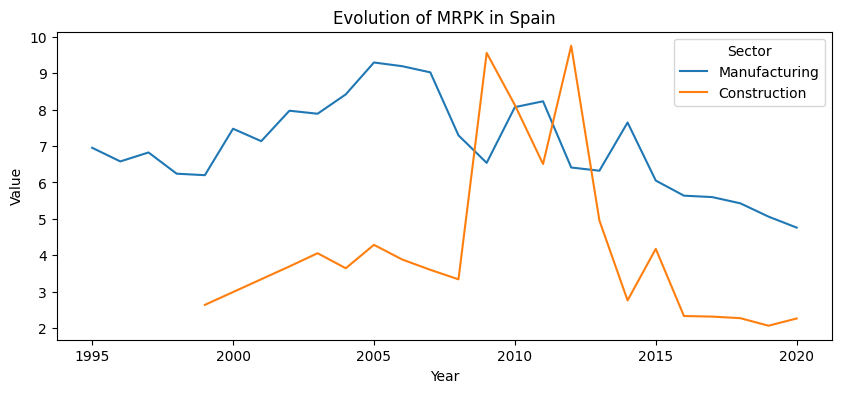

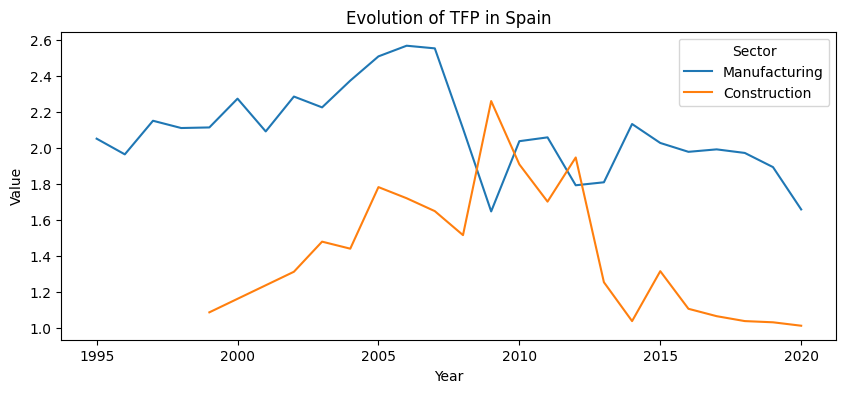

In [5]:
plot_series(data, 'ES', 'mrpk', 'Evolution of MRPK in Spain', category='Sector')
plt.show()
plot_series(data, 'ES', 'tfp', 'Evolution of TFP in Spain', category='Sector')
plt.show()

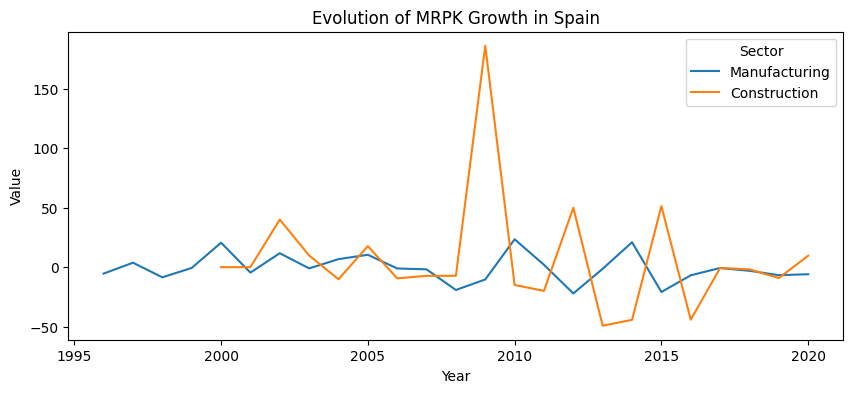

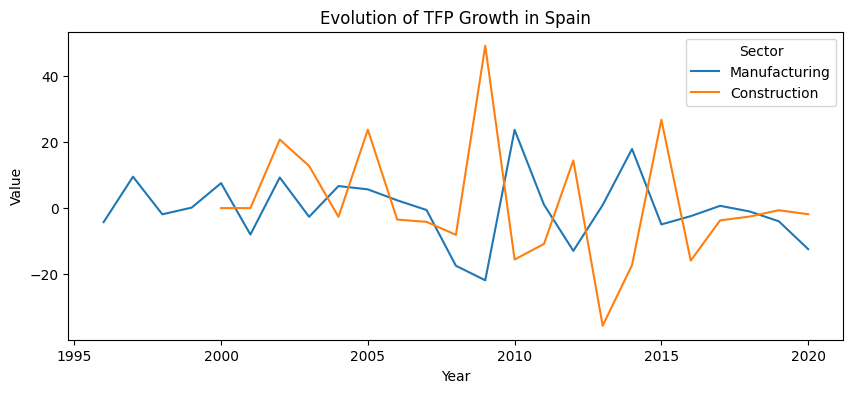

In [6]:
plot_series(data, 'ES', 'mrpk growth', 'Evolution of MRPK Growth in Spain', category='Sector')
plt.show()
plot_series(data, 'ES', 'tfp growth', 'Evolution of TFP Growth in Spain', category='Sector')
plt.show()

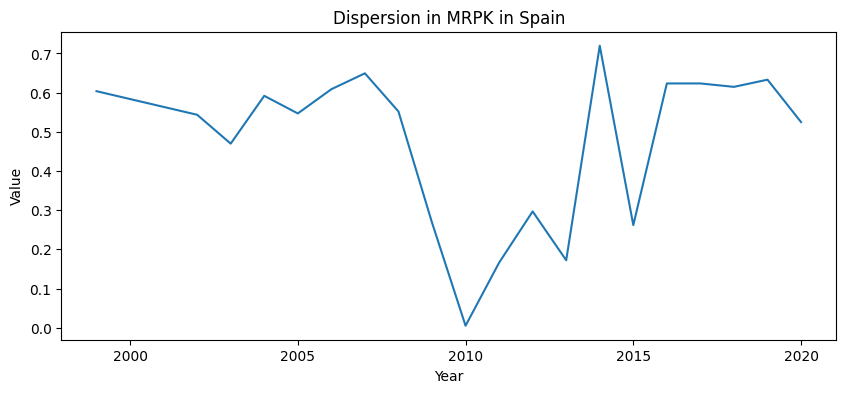

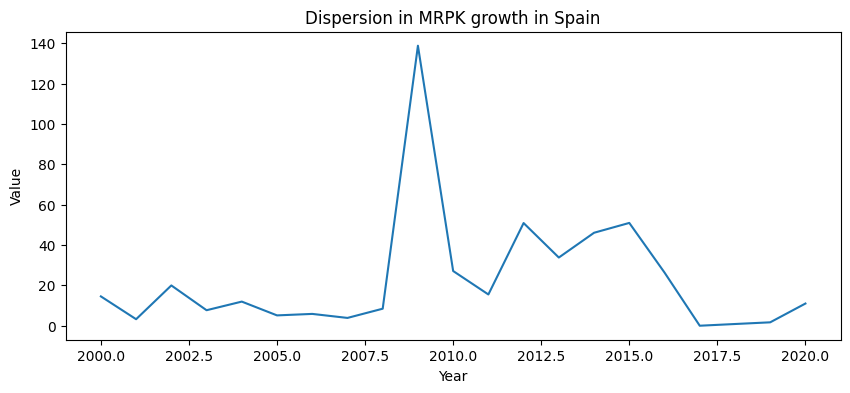

In [7]:
#calculate the dispersion between the two sectors
dispersion = data.groupby(["country", "year"]).agg({"ln mrpk": 'std', 'mrpk growth': 'std'}).reset_index()
plot_series(dispersion, 'ES', 'ln mrpk', 'Dispersion in MRPK in Spain')
plt.show()

plot_series(dispersion, 'ES', 'mrpk growth', 'Dispersion in MRPK growth in Spain')
plt.show()

In [8]:
#compare dispersion before and after crisis
before = dispersion[dispersion["year"] == 2003]
after  = dispersion[dispersion["year"] == 2009]
comparison = before.merge(after, on="country", suffixes=(" 2003", " 2009"))
comparison['change mrpk growth'] = comparison['mrpk growth 2009'] - comparison['mrpk growth 2003']
comparison['change ln mrpk'] = comparison['ln mrpk 2009'] - comparison['ln mrpk 2003']
comparison

,country,year 2003,ln mrpk 2003,mrpk growth 2003,year 2009,ln mrpk 2009,mrpk growth 2009,change mrpk growth,change ln mrpk
0,AT,2003,0.182087,3.606676,2009,0.810364,4.085943,0.479267,0.628278
1,BE,2003,0.099892,17.635864,2009,0.111023,15.748184,-1.887680,0.011131
2,BG,2003,0.586542,15.116892,2009,0.552197,31.466240,16.349348,-0.034345
3,CY,2003,0.873259,28.230076,2009,1.628838,124.245299,96.015222,0.755579
4,CZ,2003,0.195574,4.291760,2009,0.312396,1.045979,-3.245781,0.116823
5,DE,2003,0.684879,6.040010,2009,0.986300,15.377515,9.337504,0.301421
6,DK,2003,0.350658,11.318828,2009,0.781555,21.014015,9.695187,0.430898
7,EE,2003,0.127999,33.354874,2009,0.205343,82.750739,49.395865,0.077343
8,EL,2003,0.161337,NaN,2009,0.395759,20.491644,NaN,0.234422
9,ES,2003,0.469763,7.681942,2009,0.268298,138.800671,131.118729,-0.201466


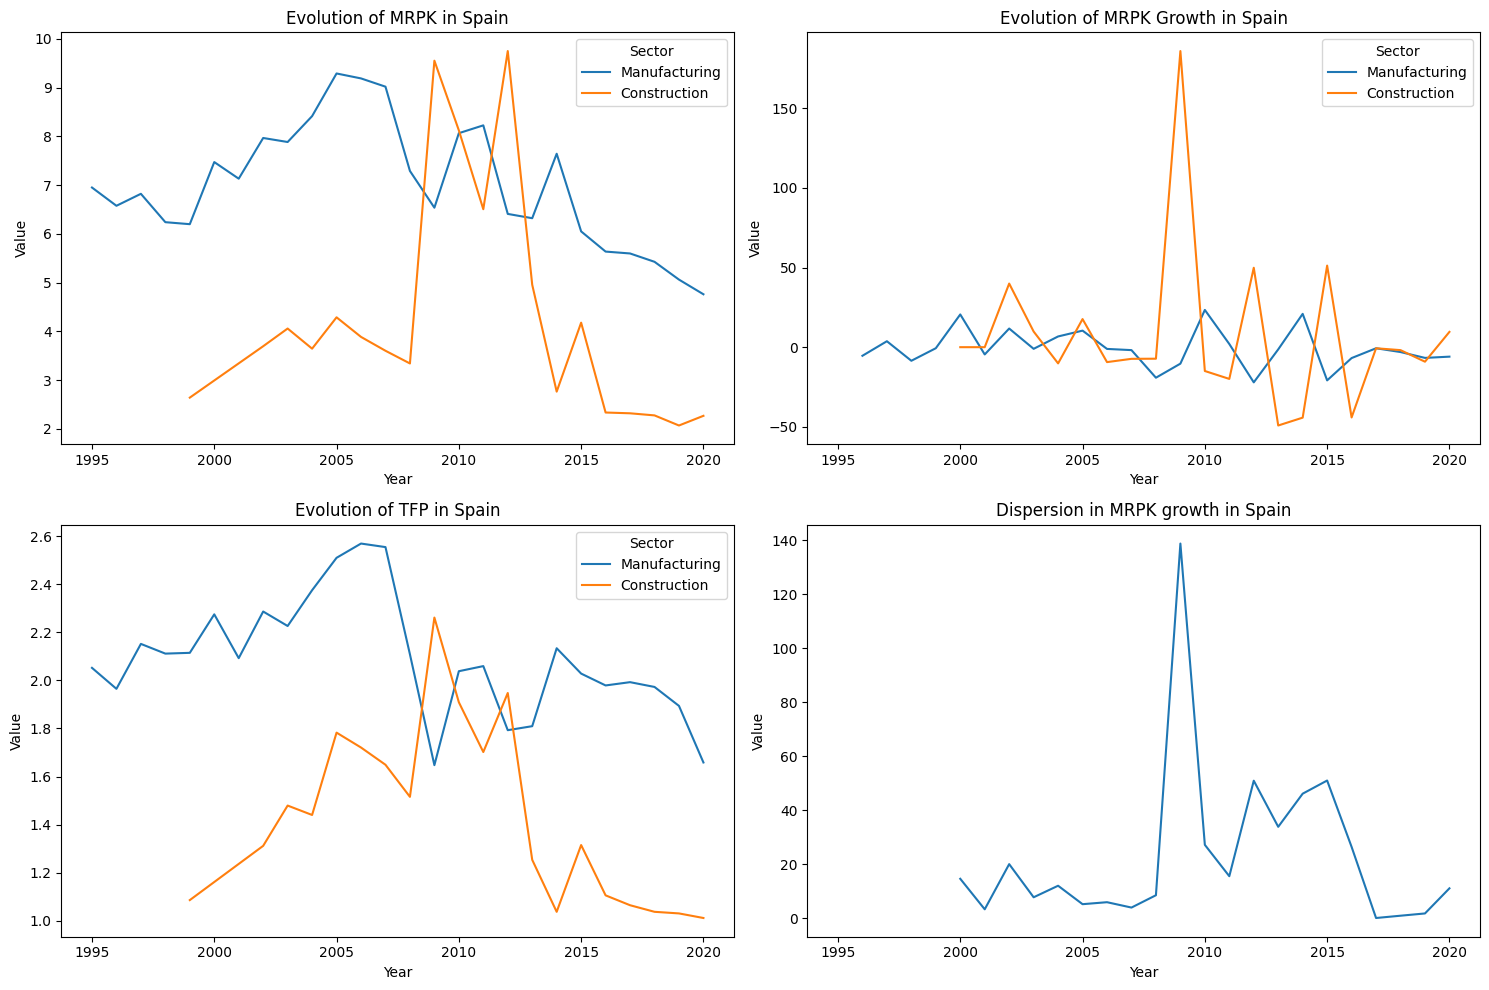

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex='row')

plot_series(data, 'ES', 'mrpk', 'Evolution of MRPK in Spain', category='Sector', ax=axes[0,0])
plot_series(data, 'ES', 'tfp', 'Evolution of TFP in Spain', category='Sector', ax=axes[1,0])
plot_series(data, 'ES', 'mrpk growth', 'Evolution of MRPK Growth in Spain', category='Sector', ax=axes[0,1])
plot_series(dispersion, 'ES', 'mrpk growth', 'Dispersion in MRPK growth in Spain', ax=axes[1,1])

plt.tight_layout()
plt.show()
fig.savefig('spain results.png')

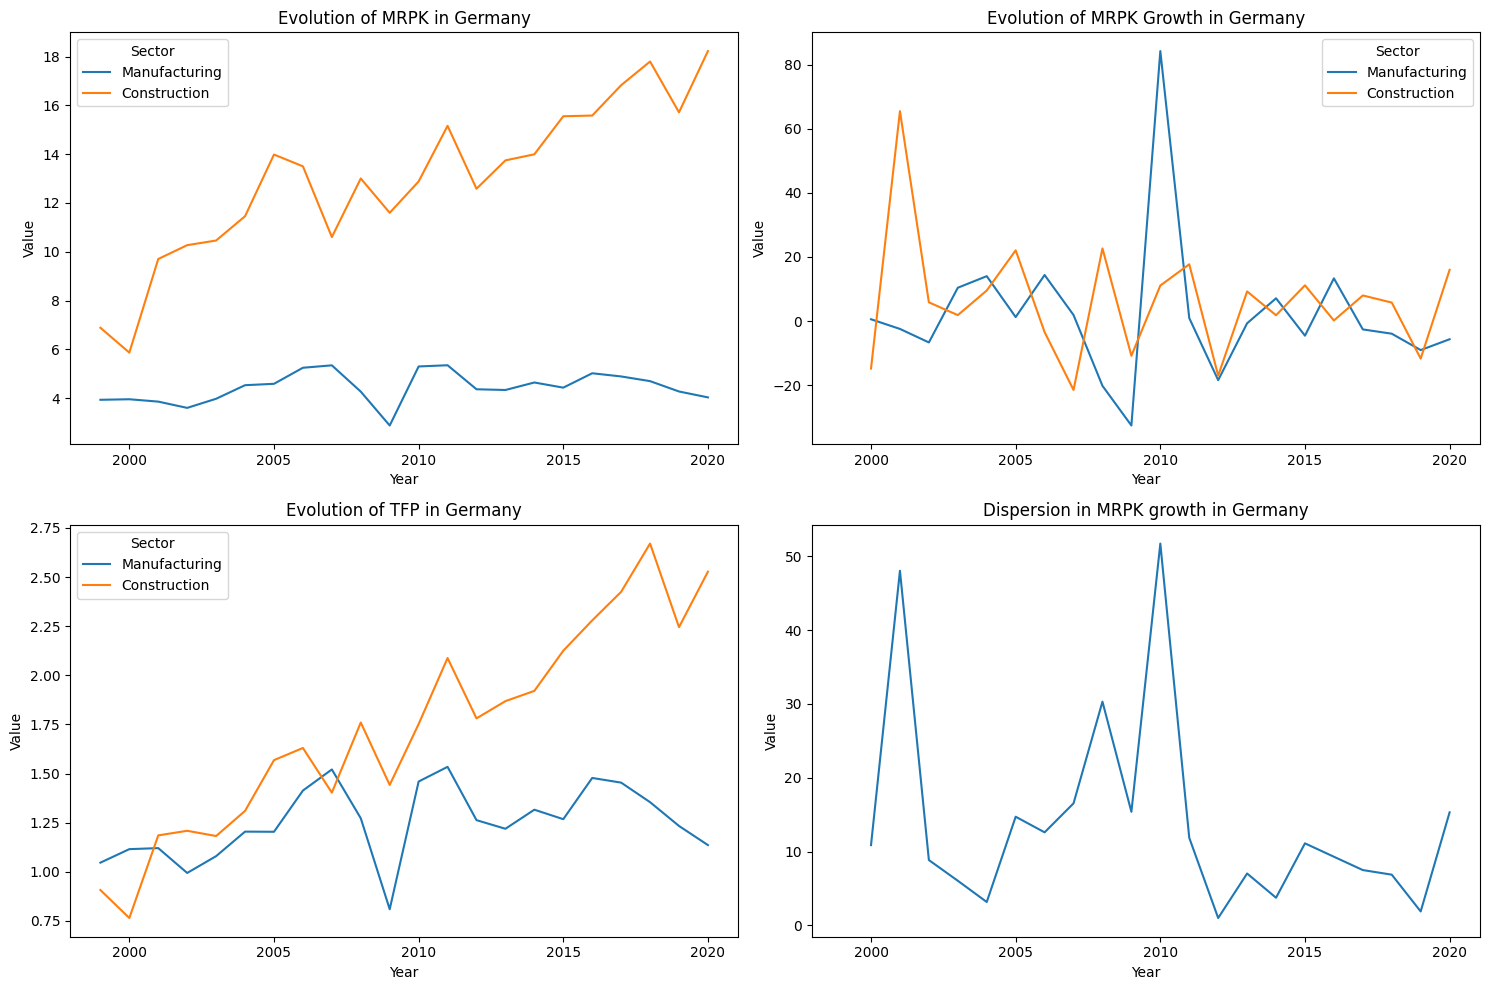

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex='row')

plot_series(data, 'DE', 'mrpk', 'Evolution of MRPK in Germany', category='Sector', ax=axes[0,0])
plot_series(data, 'DE', 'tfp', 'Evolution of TFP in Germany', category='Sector', ax=axes[1,0])
plot_series(data, 'DE', 'mrpk growth', 'Evolution of MRPK Growth in Germany', category='Sector', ax=axes[0,1])
plot_series(dispersion, 'DE', 'mrpk growth', 'Dispersion in MRPK growth in Germany', ax=axes[1,1])

plt.tight_layout()
plt.show()
fig.savefig('germany results.png')

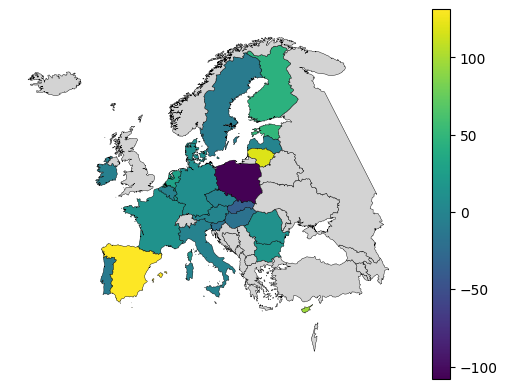

In [11]:
import geopandas as gpd

geo = gpd.read_file('europe.geojson')[['ISO2', 'geometry']]
geo = geo.merge(comparison, left_on='ISO2', right_on='country', how='left')
geo = geo.set_geometry('geometry')


ax = geo.plot(column='change mrpk growth', legend=True, edgecolor='black', linewidth=0.3, missing_kwds={
        "color": "lightgrey",  # color for NaN values
        "label": "No data"     # optional legend label
    })
ax.set_axis_off()
plt.savefig('map.png')
plt.show()